In [1]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from nnfabrik.builder import get_data, get_trainer

from sensorium2020_adapted import stacked_core_full_gauss_readout
from wandb_trainer import standard_trainer

random_seed = 42

device = "cuda:7"
torch.cuda.set_device(device)

In [2]:
# loading the SENSORIUM+ dataset
filenames = [
    "/srv/user/polina/sensorium/sensorium/notebooks/data/static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6.zip",
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": False,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataset_config["exclude"] = 'images'

loader = get_data(dataset_fn, dataset_config)

In [3]:
model_config = {
    "pad_input": False,
    "stack": -1,
    "layers": 4,
    "input_kern": 9,
    "gamma_input": 6.3831,
    "gamma_readout": 0.0076,
    "hidden_kern": 7,
    "hidden_channels": 64,
    "depth_separable": True,
    "grid_mean_predictor": {
        "type": "cortex",
        "input_dimensions": 2,
        "hidden_layers": 1,
        "hidden_features": 30,
        "final_tanh": True,
    },
    "init_sigma": 0.1,
    "init_mu_range": 0.3,
    "gauss_type": "full",
}

model_config["shifter"] = False
model_config["perspective"] = True

In [4]:
translations = []
rotations = []

for _ in range(10):
    model = stacked_core_full_gauss_readout(loader, random_seed, **model_config)

    validation_score, trainer_output, state_dict = standard_trainer(
        model, 
        loader, 
        random_seed, 
        max_iter=200, 
        verbose=False, 
        lr_decay_steps=4, 
        avg_loss=False, 
        lr_init=0.009, 
        track_training=False, 
        device=device,
        wandb_project='perspective'
    )

    translation, rotation = list(model.perspective.parameters())[12:14]
    translation = translation.cpu().detach().numpy()
    rotation = rotation.cpu().detach().numpy()

    translations.append(translation)
    rotations.append(rotation)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: nathan-soeding (nathan-soeding-uni-goettingen) to https://api.wandb.ai. Use `wandb login --relogin` to forc

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/gaussian.py:582: UserWarning: the specified feature map dimension is not the readout's expected input dimension
  warnings.warn("the specified feature map dimension is not the readout's expected input dimension")
Epoch 84: 100%|██████████| 35/35 [00:03<00:00, 11.59it/s]


final/validation_corr_all,▁
final/validation_corr_mean,▁
val/correlation,▁▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇█████████████████████
val/poisson_loss,█▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
final/validation_corr_all,0.35568
final/validation_corr_mean,0.35568
val/correlation,0.35388
val/poisson_loss,2186055.25


/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/gaussian.py:582: UserWarning: the specified feature map dimension is not the readout's expected input dimension
  warnings.warn("the specified feature map dimension is not the readout's expected input dimension")
Epoch 87: 100%|██████████| 35/35 [00:03<00:00, 11.39it/s]


...

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/gaussian.py:582: UserWarning: the specified feature map dimension is not the readout's expected input dimension
  warnings.warn("the specified feature map dimension is not the readout's expected input dimension")
Epoch 96: 100%|██████████| 35/35 [00:03<00:00, 11.18it/s]


final/validation_corr_all,▁
final/validation_corr_mean,▁
val/correlation,▁▂▃▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇█████████████████████
val/poisson_loss,█▆▅▅▄▃▃▂▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▁▂▁▂▂▁▁▁▁▁▁▁▁▁▁
final/validation_corr_all,0.35964
final/validation_corr_mean,0.35964
val/correlation,0.35895
val/poisson_loss,2177648.5


/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/gaussian.py:582: UserWarning: the specified feature map dimension is not the readout's expected input dimension
  warnings.warn("the specified feature map dimension is not the readout's expected input dimension")
Epoch 86: 100%|██████████| 35/35 [00:03<00:00, 11.54it/s]


final/validation_corr_all,▁
final/validation_corr_mean,▁
val/correlation,▁▃▄▅▆▇▇▇▇▇▇▇▇▇▇█▇▇██████████████████████
val/poisson_loss,█▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
final/validation_corr_all,0.36058
final/validation_corr_mean,0.36058
val/correlation,0.36016
val/poisson_loss,2174871.75


In [15]:
translations = np.array(translations)

In [9]:
rotations = np.array(rotations)

In [29]:
translations, rotations * 180 / np.pi

(array([[-0.07263226, -0.03689421,  0.46748865],
        [-0.06275244, -0.03393039,  0.46179256],
        [-0.04918091, -0.04066863,  0.44308412],
        [-0.04451549, -0.03899693,  0.4763559 ],
        [-0.04119612, -0.04135809,  0.47607028],
        [-0.04891539, -0.05293309,  0.50741976],
        [-0.03056788, -0.04135188,  0.47130293],
        [-0.07458533, -0.03882957,  0.46552932],
        [-0.03217193, -0.05021892,  0.48483598],
        [-0.04662136, -0.04640598,  0.4808301 ]], dtype=float32),
 array([[-5.4550757, 14.864457 , 11.237429 ],
        [-4.628664 , 14.942373 , 11.302394 ],
        [-7.0764365, 16.738373 ,  8.5106945],
        [-6.72527  , 18.111792 , 10.795778 ],
        [-6.123689 , 18.600594 , 10.080494 ],
        [-8.426318 , 18.570244 , 10.509509 ],
        [-6.384404 , 18.872076 , 10.968002 ],
        [-4.7309785, 14.083956 , 10.858602 ],
        [-6.9899354, 18.884232 , 11.130397 ],
        [-5.7998633, 17.599556 , 11.416039 ]], dtype=float32))

In [25]:
translations.mean(axis=0)

array([-0.05031391, -0.04215877,  0.473471  ], dtype=float32)

In [19]:
translations.std(axis=0)

array([0.01447272, 0.00564895, 0.01585631], dtype=float32)

In [27]:
rotations.mean(axis=0) * 180 / np.pi

array([-6.2340627, 17.126764 , 10.680933 ], dtype=float32)

In [21]:
rotations.std(axis=0) * 180 / np.pi

array([1.0952127 , 1.7573715 , 0.81641364], dtype=float32)

In [32]:
data_key = '23343-5-17'
batches = list(iter(loader['train'][data_key]))

pupil_center = [batch[2] for batch in batches]
img = [batch[0] for batch in batches]

pupil_center = torch.cat(pupil_center)
img = torch.cat(img)

tensor(0, device='cuda:7')
img shape: torch.Size([4466, 1, 36, 64])
perspective output shape: torch.Size([10, 36, 54])


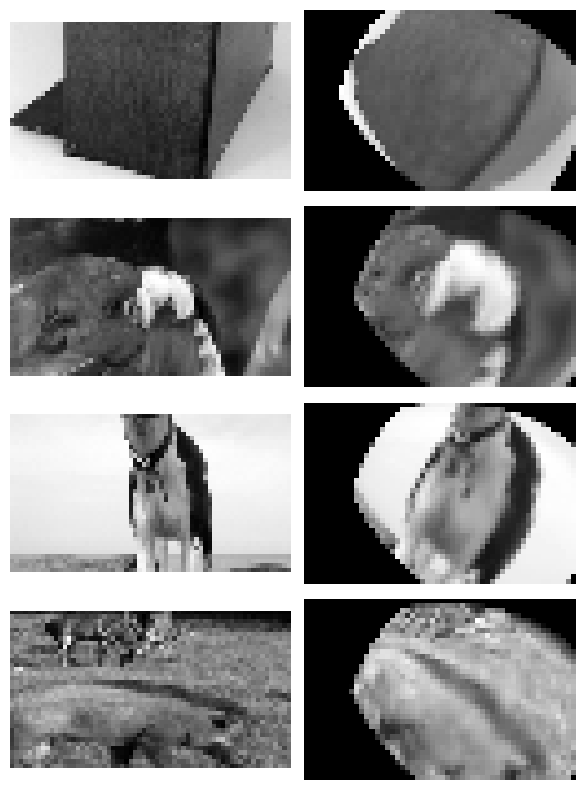

In [33]:
fig, ax = plt.subplots(4, 2, figsize=(6, 8))

out = model.perspective[data_key](img[:10], pupil_center[:10])
print(out.isnan().sum())
out = out[:, 0].detach().cpu()

print("img shape:", img.shape)
print("perspective output shape:", out.shape)

for i in range(4):
    ax[i, 0].imshow(img.cpu()[i, 0], cmap="gray")
    ax[i, 0].axis("off")
    ax[i, 1].imshow(out[i], cmap="gray")
    ax[i, 1].axis("off")

plt.tight_layout()
plt.savefig('plots/perspective_outputs', pad_inches=0)
plt.show()

In [34]:
out = model.perspective[data_key](img, pupil_center)
out = out[:, 0].detach().cpu()

In [41]:
angles = model.perspective[data_key].retina.mlp(pupil_center).detach().cpu()

In [46]:
angles.mean(axis=0) * 180 / np.pi

tensor([ -1.9487,  -8.6460, -14.5371])